In [8]:
import warnings
warnings.filterwarnings(action='ignore') 

import datetime
import pandas as pd
import numpy as np
import csv
import folium
from folium.plugins import HeatMap 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans    ##  K-means 임포트
from sklearn.metrics import silhouette_score
import scipy as sp
from scipy.cluster.hierarchy import dendrogram, linkage
import statsmodels.formula.api as smf
from dateutil.relativedelta import relativedelta
# import setuptools.dist
from yellowbrick.cluster import KElbowVisualizer
from mpl_toolkits.mplot3d import Axes3D
import networkx as nx
from wordcloud import WordCloud
import re
from collections import Counter
from PIL import Image
plt.rc('font',family='D2CodingLigature Nerd Font')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시

### wordcloud_002.txt _ 워드클라우드

In [2]:
# 1. 파일 읽기
txt2 = open('../../data/wordcloud_002.txt','rt', encoding='UTF-8').read()
txt2

'20만 명이 넘는 흑인과 백인들이 경청하러 왔다. 그들은 비행기로, 자동차로, 버스로, 기차로 그리고 걸어서 왔다. 그들은 흑인의 평등한 권리를 요구하기 위해 워싱턴으로 온 것이었다. 그리고 그들이 기념관의 계단에서 들은 꿈은 한 세대의 꿈이 되었다.\n지금이야말로 바로 민주주의의 약속을 현실로 실현할 때입니다. 지금이야말로 바로 어둡고 쓸쓸한 인종 차별의 골짜기로부터 분기하여 인종적 정의의 햇볕 길로 나아가야 할 때입니다.\n흑인에게 시민권이 주어지기 전까지 미국에는 안식도 평온도 없을 것입니다. 정의의 밝은 날이 오기까지 반란의 회오리바람이 계속 우리 국가의 기반을 뒤흔들 것입니다.\n그러나 나는 정의의 궁전으로 들어가는 문턱에 서 있는 여러분에게 해야 할 말이 있습니다. 우리의 정당한 지위를 얻는 과정에서 우리가 부당한 행위를 해서는 안 됩니다. 흑인 사회를 집어 삼켜버린 놀라운 새 투지가 모든 백인에 대한 불신으로 이어져서는 안 됩니다. 오늘 그들이 이 자리에 참석한 사실이 입증하듯, 우리의 많은 백인 형제들은 그들의 자유가 어쩔 수 없이 우리의 자유에 결부되어 있다는 사실을 깨닫게 되었기 때문입니다.\n고난 속의 영예는 보상 받는다는 믿음을 가지고 계속 일합시다. 미시시피 주로, 앨라배마 주로, 루이지애나 주로 그리고 우리 북부 여러 도시의 빈민가와 게토로 돌아가십시오. 그리고 이러한 현실은 변화될 수 있는 것일 뿐만 아니라, 또한 변화될 것임을 아십시오.\n나는 오늘 나의 여러 친구들에게 말하노니, 나는 어려움과 좌절의 순간이 있었지만 아직도 꿈을 가지고 있습니다. 그것은 아메리칸 드림에 깊이 뿌리 박은 꿈입니다.\n나는 언젠가는 이 나라 국민들이 분기하여 “우리는 모든 인간이 평등하게 창조되었음을 자명한 진리로 삼는다”는 이 나라 국민 신조의 참 뜻을 체험하게 될 것이라는 꿈을 가지고 있습니다.\n나는 언젠가는 조지아 주의 붉은 언덕에서 옛 노예의 자손들이 옛 노예 소유주의 자손들과 함께 형제애의 테이블에 앉을 수 있게 되리라는 꿈을 가지고 있습

In [3]:
# 2. 한글과 공백만 남기기 (특수문자 제거)
clean_txt2 = re.sub(r"[^가-힣\s]", " ", txt2)
clean_txt2

'  만 명이 넘는 흑인과 백인들이 경청하러 왔다  그들은 비행기로  자동차로  버스로  기차로 그리고 걸어서 왔다  그들은 흑인의 평등한 권리를 요구하기 위해 워싱턴으로 온 것이었다  그리고 그들이 기념관의 계단에서 들은 꿈은 한 세대의 꿈이 되었다 \n지금이야말로 바로 민주주의의 약속을 현실로 실현할 때입니다  지금이야말로 바로 어둡고 쓸쓸한 인종 차별의 골짜기로부터 분기하여 인종적 정의의 햇볕 길로 나아가야 할 때입니다 \n흑인에게 시민권이 주어지기 전까지 미국에는 안식도 평온도 없을 것입니다  정의의 밝은 날이 오기까지 반란의 회오리바람이 계속 우리 국가의 기반을 뒤흔들 것입니다 \n그러나 나는 정의의 궁전으로 들어가는 문턱에 서 있는 여러분에게 해야 할 말이 있습니다  우리의 정당한 지위를 얻는 과정에서 우리가 부당한 행위를 해서는 안 됩니다  흑인 사회를 집어 삼켜버린 놀라운 새 투지가 모든 백인에 대한 불신으로 이어져서는 안 됩니다  오늘 그들이 이 자리에 참석한 사실이 입증하듯  우리의 많은 백인 형제들은 그들의 자유가 어쩔 수 없이 우리의 자유에 결부되어 있다는 사실을 깨닫게 되었기 때문입니다 \n고난 속의 영예는 보상 받는다는 믿음을 가지고 계속 일합시다  미시시피 주로  앨라배마 주로  루이지애나 주로 그리고 우리 북부 여러 도시의 빈민가와 게토로 돌아가십시오  그리고 이러한 현실은 변화될 수 있는 것일 뿐만 아니라  또한 변화될 것임을 아십시오 \n나는 오늘 나의 여러 친구들에게 말하노니  나는 어려움과 좌절의 순간이 있었지만 아직도 꿈을 가지고 있습니다  그것은 아메리칸 드림에 깊이 뿌리 박은 꿈입니다 \n나는 언젠가는 이 나라 국민들이 분기하여  우리는 모든 인간이 평등하게 창조되었음을 자명한 진리로 삼는다 는 이 나라 국민 신조의 참 뜻을 체험하게 될 것이라는 꿈을 가지고 있습니다 \n나는 언젠가는 조지아 주의 붉은 언덕에서 옛 노예의 자손들이 옛 노예 소유주의 자손들과 함께 형제애의 테이블에 앉을 수 있게 되리라는 꿈을 가지고 있습

In [4]:
# 3. 단어 리스트 만들기 (공백 기준)
words2 = clean_txt2.split()
words2

['만',
 '명이',
 '넘는',
 '흑인과',
 '백인들이',
 '경청하러',
 '왔다',
 '그들은',
 '비행기로',
 '자동차로',
 '버스로',
 '기차로',
 '그리고',
 '걸어서',
 '왔다',
 '그들은',
 '흑인의',
 '평등한',
 '권리를',
 '요구하기',
 '위해',
 '워싱턴으로',
 '온',
 '것이었다',
 '그리고',
 '그들이',
 '기념관의',
 '계단에서',
 '들은',
 '꿈은',
 '한',
 '세대의',
 '꿈이',
 '되었다',
 '지금이야말로',
 '바로',
 '민주주의의',
 '약속을',
 '현실로',
 '실현할',
 '때입니다',
 '지금이야말로',
 '바로',
 '어둡고',
 '쓸쓸한',
 '인종',
 '차별의',
 '골짜기로부터',
 '분기하여',
 '인종적',
 '정의의',
 '햇볕',
 '길로',
 '나아가야',
 '할',
 '때입니다',
 '흑인에게',
 '시민권이',
 '주어지기',
 '전까지',
 '미국에는',
 '안식도',
 '평온도',
 '없을',
 '것입니다',
 '정의의',
 '밝은',
 '날이',
 '오기까지',
 '반란의',
 '회오리바람이',
 '계속',
 '우리',
 '국가의',
 '기반을',
 '뒤흔들',
 '것입니다',
 '그러나',
 '나는',
 '정의의',
 '궁전으로',
 '들어가는',
 '문턱에',
 '서',
 '있는',
 '여러분에게',
 '해야',
 '할',
 '말이',
 '있습니다',
 '우리의',
 '정당한',
 '지위를',
 '얻는',
 '과정에서',
 '우리가',
 '부당한',
 '행위를',
 '해서는',
 '안',
 '됩니다',
 '흑인',
 '사회를',
 '집어',
 '삼켜버린',
 '놀라운',
 '새',
 '투지가',
 '모든',
 '백인에',
 '대한',
 '불신으로',
 '이어져서는',
 '안',
 '됩니다',
 '오늘',
 '그들이',
 '이',
 '자리에',
 '참석한',
 '사실이',
 '입증하듯',
 '우리의',
 '많은',
 '백인',
 '형제

In [5]:
words22 = [i   for i in words2  if (len(i) >=2) & (len(i)<=6)  ]
words22

['명이',
 '넘는',
 '흑인과',
 '백인들이',
 '경청하러',
 '왔다',
 '그들은',
 '비행기로',
 '자동차로',
 '버스로',
 '기차로',
 '그리고',
 '걸어서',
 '왔다',
 '그들은',
 '흑인의',
 '평등한',
 '권리를',
 '요구하기',
 '위해',
 '워싱턴으로',
 '것이었다',
 '그리고',
 '그들이',
 '기념관의',
 '계단에서',
 '들은',
 '꿈은',
 '세대의',
 '꿈이',
 '되었다',
 '지금이야말로',
 '바로',
 '민주주의의',
 '약속을',
 '현실로',
 '실현할',
 '때입니다',
 '지금이야말로',
 '바로',
 '어둡고',
 '쓸쓸한',
 '인종',
 '차별의',
 '골짜기로부터',
 '분기하여',
 '인종적',
 '정의의',
 '햇볕',
 '길로',
 '나아가야',
 '때입니다',
 '흑인에게',
 '시민권이',
 '주어지기',
 '전까지',
 '미국에는',
 '안식도',
 '평온도',
 '없을',
 '것입니다',
 '정의의',
 '밝은',
 '날이',
 '오기까지',
 '반란의',
 '회오리바람이',
 '계속',
 '우리',
 '국가의',
 '기반을',
 '뒤흔들',
 '것입니다',
 '그러나',
 '나는',
 '정의의',
 '궁전으로',
 '들어가는',
 '문턱에',
 '있는',
 '여러분에게',
 '해야',
 '말이',
 '있습니다',
 '우리의',
 '정당한',
 '지위를',
 '얻는',
 '과정에서',
 '우리가',
 '부당한',
 '행위를',
 '해서는',
 '됩니다',
 '흑인',
 '사회를',
 '집어',
 '삼켜버린',
 '놀라운',
 '투지가',
 '모든',
 '백인에',
 '대한',
 '불신으로',
 '이어져서는',
 '됩니다',
 '오늘',
 '그들이',
 '자리에',
 '참석한',
 '사실이',
 '입증하듯',
 '우리의',
 '많은',
 '백인',
 '형제들은',
 '그들의',
 '자유가',
 '어쩔',
 '없이',
 '우리의',
 '자유에',
 '결부되어',


In [6]:
# 4. 단어 빈도 계산
cnt2 = Counter(words22)
cnt2

Counter({'자유가': 11,
         '울리게': 10,
         '모든': 8,
         '합시다': 8,
         '나는': 6,
         '있습니다': 6,
         '그리고': 5,
         '가지고': 5,
         '주의': 5,
         '꿈을': 4,
         '꿈이': 3,
         '정의의': 3,
         '것입니다': 3,
         '우리의': 3,
         '오늘': 3,
         '그들의': 3,
         '주로': 3,
         '언젠가는': 3,
         '마침내': 3,
         '해방되었도다': 3,
         '흑인과': 2,
         '왔다': 2,
         '그들은': 2,
         '그들이': 2,
         '지금이야말로': 2,
         '바로': 2,
         '때입니다': 2,
         '분기하여': 2,
         '계속': 2,
         '우리': 2,
         '있는': 2,
         '우리가': 2,
         '됩니다': 2,
         '백인': 2,
         '미시시피': 2,
         '여러': 2,
         '변화될': 2,
         '아니라': 2,
         '나의': 2,
         '나라': 2,
         '우리는': 2,
         '조지아': 2,
         '있게': 2,
         '되리라는': 2,
         '판단': 2,
         '산맥으로부터': 2,
         '명이': 1,
         '넘는': 1,
         '백인들이': 1,
         '경청하러': 1,
         '비행기로': 1,
         '자동차로': 1,
         '

In [9]:
# 5. 워드클라우드 생성
m = np.array(Image.open('../../data/001.png'))  ## 마스크로 사용할 이미지

wcs2 = WordCloud(
                font_path='/home/erion/.local/share/fonts/d2codingligature-nerd-font/D2CodingLigatureNerdFont-Regular.ttf',  # 폰트 경로 필수!
                background_color = 'white',
                width=1000, height=700,
                max_words=100,           ## 워드클라우드에 나타낼 단어의 최대 개수
                max_font_size=200,       ## 폰트 최대 사이즈
                colormap = 'Accent',
                mask=m                   ## 마스크 모양으로 사용할 이미지가 저장된 변수
                )

cloud2 = wcs2.generate_from_frequencies(cnt2)

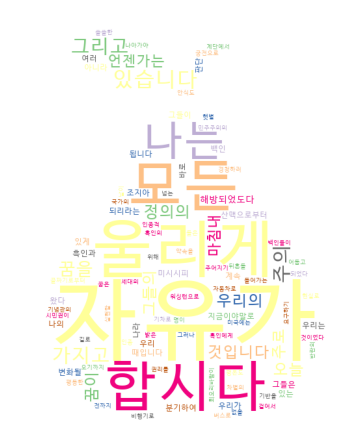

In [11]:
# 6. 시각화
plt.imshow(cloud2.to_image())
plt.axis('off')
plt.savefig('../../data/wordcloud002.png')